# Roxy helpers tutorial

This notebook demonstrates how to use the **RoxyHelpers** high-level API
to perform common workflows with minimal boilerplate.

We will:

1. Create a small toy dataset of protein-like sequences with labels.
2. Use `RoxyHelpers.describe_sequences` to:
   - build a `RoxyDataset`,
   - compute sequence descriptors (global and AAIndex, if available),
   - run EDA and build a `DatasetReport`,
   - generate Markdown and HTML reports,
   - optionally compute a low-dimensional embedding (PCA).
3. Inspect and briefly visualise the results.
4. Use `RoxyHelpers.basic_eda_report` on an arbitrary feature matrix.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from roxy.helpers import RoxyHelpers
from roxy.viz import plot_embedding

## 1. Build a toy sequence dataset

We create a small DataFrame with:

- an `id` column used as index,
- a `sequence` column with short protein-like sequences,
- a `label` column indicating a simple class (`"basic"` or `"acidic"`).

In [11]:
toy_data = {
    "id": [
        "prot_1",
        "prot_2",
        "prot_3",
        "prot_4",
        "prot_5",
        "prot_6",
        "prot_7",
        "prot_8",
        "prot_9",
        "prot_10",
    ],
    "sequence": [
        "KKKKKKKKKKAAAAAAEEEE",
        "RRRRRRRRRRVVVVVVDDDD",
        "KKRRKKRRKKRRKKRREEEE",
        "DDDDDDDDDDGGGGGGKKKK",
        "EEEEEEEEEEAAAAAAKKKK",
        "DDEEDDDEEDDEEDDQQQQQ",
        "ACDEFGHIKLMNPQRSTVWY",
        "AAAAAEEEEEGGGGGDDDDD",
        "RRRRRKKKKKAAAAAIIIII",
        "DDDDDEEEEEFFFFFSSSSS",
    ],
    "label": [
        "basic",
        "basic",
        "basic",
        "acidic",
        "acidic",
        "acidic",
        "mixed",
        "acidic",
        "basic",
        "acidic",
    ],
}

df = pd.DataFrame(toy_data).set_index("id")
df

,sequence,label
id,,
prot_1,KKKKKKKKKKAAAAAAEEEE,basic
prot_2,RRRRRRRRRRVVVVVVDDDD,basic
prot_3,KKRRKKRRKKRRKKRREEEE,basic
prot_4,DDDDDDDDDDGGGGGGKKKK,acidic
prot_5,EEEEEEEEEEAAAAAAKKKK,acidic
prot_6,DDEEDDDEEDDEEDDQQQQQ,acidic
prot_7,ACDEFGHIKLMNPQRSTVWY,mixed
prot_8,AAAAAEEEEEGGGGGDDDDD,acidic
prot_9,RRRRRKKKKKAAAAAIIIII,basic


## 2. Describe sequences with `RoxyHelpers.describe_sequences`

The `describe_sequences` helper performs the following steps:

1. Builds a `RoxyDataset` from the input DataFrame.
2. Computes global sequence descriptors (always).
3. Optionally computes AAIndex-based descriptors if the `"seq_aaindex"`
   descriptor engine is registered.
4. Combines the selected feature blocks into a single feature matrix.
5. Builds a dataset-level EDA report.
6. Renders the report as Markdown and HTML.
7. Optionally runs a projection method (PCA by default) to obtain a
   low-dimensional embedding.


In [12]:
result = RoxyHelpers.describe_sequences(
    df,
    seq_col="sequence",
    y="label",  # we pass the name of the label column
    dataset_name="Toy sequences",
    use_aaindex=True,         # if seq_aaindex is registered, it will be used
    feature_key_prefix="",    # no prefix in this example
    task_type=None,           # let Roxy infer task type from y
    project_method="pca",     # compute a PCA embedding
    n_components=2,
    random_state=42,
)

result

/home/david/Desktop/library_implementation/roxy_library/roxy/report/markdown.py:145: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[float_cols] = df[float_cols].applymap(


SequenceDescribeResult(dataset=<RoxyDataset(name='Toy sequences', n_samples=10, n_raw_columns=2)
  feature_blocks: seq_global
  has_y: True>, feature_keys=['seq_global'], X=         length  aa_frac_C  aa_frac_G  aa_frac_H  aa_frac_A  aa_frac_N  \
id                                                                       
prot_1     20.0       0.00       0.00       0.00       0.30       0.00   
prot_2     20.0       0.00       0.00       0.00       0.00       0.00   
prot_3     20.0       0.00       0.00       0.00       0.00       0.00   
prot_4     20.0       0.00       0.30       0.00       0.00       0.00   
prot_5     20.0       0.00       0.00       0.00       0.30       0.00   
prot_6     20.0       0.00       0.00       0.00       0.00       0.00   
prot_7     20.0       0.05       0.05       0.05       0.05       0.05   
prot_8     20.0       0.00       0.25       0.00       0.25       0.00   
prot_9     20.0       0.00       0.00       0.00       0.25       0.00   
prot_10    20

## 3. Inspect the resulting dataset and feature matrix

The helper returns a `SequenceDescribeResult` object that aggregates:

- the `RoxyDataset` instance,
- the list of feature blocks used,
- the combined feature matrix `X`,
- the aligned labels `y`,
- the `DatasetReport` object,
- the Markdown and HTML renderings,
- an optional low-dimensional embedding (here PCA).

In [13]:
# Feature blocks attached to the dataset
result.dataset.feature_blocks

['seq_global']

In [14]:
# Combined feature matrix used for EDA and projection
result.X.head()

,length,aa_frac_C,aa_frac_G,aa_frac_H,aa_frac_A,aa_frac_N,aa_frac_D,aa_frac_L,aa_frac_R,aa_frac_T,...,boman_index,net_charge_pH,fcr,ncpr,donors_per_residue,acceptors_per_residue,aa_entropy,lc_k1,lc_k2,lc_k3
id,,,,,,,,,,,,,,,,,,,,,
prot_1,20.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,...,-0.848,6.001924,0.7,0.300096,0.5,0.2,1.485475,0.15,0.263158,0.388889
prot_2,20.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.5,0.0,...,-0.730,6.000848,0.7,0.300042,0.5,0.2,1.485475,0.15,0.263158,0.388889
prot_3,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,...,-1.204,12.002530,1.0,0.600127,0.8,0.2,1.521928,0.15,0.315789,0.388889
prot_4,20.0,0.0,0.3,0.0,0.0,0.0,0.5,0.0,0.0,0.0,...,-0.810,-5.996041,0.7,-0.299802,0.2,0.5,1.485475,0.15,0.263158,0.388889
prot_5,20.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,...,-1.157,-5.985529,0.7,-0.299276,0.2,0.5,1.485475,0.15,0.263158,0.388889


In [15]:
# Labels aligned with the feature matrix
result.y

id
prot_1      basic
prot_2      basic
prot_3      basic
prot_4     acidic
prot_5     acidic
prot_6     acidic
prot_7      mixed
prot_8     acidic
prot_9      basic
prot_10    acidic
Name: label, dtype: object

In [16]:
# Embedding shape (if projection was requested)
type(result.embedding), None if result.embedding is None else result.embedding.shape

(numpy.ndarray, (10, 2))

## 4. Report renderings (Markdown and HTML)

The helper already builds a dataset-level report and renders it into:

- `result.markdown` (a Markdown string),
- `result.html` (a full HTML document).

Here we inspect the first few lines of the Markdown report.


In [17]:
# Show the first 40 lines of the Markdown report
result.markdown.splitlines()[:40]

['# Roxy dataset report — Toy sequences',
 '',
 '## Overview',
 '',
 '- **Samples:** `10`',
 '- **Features:** `41`',
 '- **Task type:** `classification`',
 '- **Class distribution:**',
 '  - `acidic`: `5`',
 '  - `basic`: `4`',
 '  - `mixed`: `1`',
 '',
 '## Feature summary',
 '',
 '| name | dtype | n_missing | missing_ratio | n_unique | mean | std | min | max | skewness | kurtosis |',
 '| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |',
 '| length | float64 | 0 | 0.000 | 1 | 20.000 | 0.000 | 20.000 | 20.000 | 0.000 | 0.000 |',
 '| aa_frac_C | float64 | 0 | 0.000 | 2 | 0.005 | 0.016 | 0.000 | 0.050 | 3.162 | 10.000 |',
 '| aa_frac_G | float64 | 0 | 0.000 | 4 | 0.060 | 0.115 | 0.000 | 0.300 | 1.751 | 1.543 |',
 '| aa_frac_H | float64 | 0 | 0.000 | 2 | 0.005 | 0.016 | 0.000 | 0.050 | 3.162 | 10.000 |',
 '| aa_frac_A | float64 | 0 | 0.000 | 4 | 0.115 | 0.140 | 0.000 | 0.300 | 0.496 | -2.095 |',
 '| aa_frac_N | float64 | 0 | 0.000 | 2 | 0.005 | 0.016 | 0.000 | 0.050 | 3.

In [18]:
# Optionally, display the HTML report if running in a notebook frontend
from IPython.display import HTML

HTML(result.html)

name,dtype,n_missing,missing_ratio,n_unique,mean,std,min,max,skewness,kurtosis
length,float64,0,0.0,1,20.000,0.000,20.000,20.000,0.000,0.000
aa_frac_C,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_G,float64,0,0.0,4,0.060,0.115,0.000,0.300,1.751,1.543
aa_frac_H,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_A,float64,0,0.0,4,0.115,0.140,0.000,0.300,0.496,-2.095
aa_frac_N,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_D,float64,0,0.0,6,0.170,0.192,0.000,0.500,0.740,-0.848
aa_frac_L,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_R,float64,0,0.0,5,0.120,0.192,0.000,0.500,1.345,0.268
aa_frac_T,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000


## 5. Quick visualisation of the PCA embedding

We can use the existing `plot_embedding` helper from `roxy.viz` to
visualise the 2D PCA embedding returned by `describe_sequences`.


<Figure size 500x400 with 0 Axes>

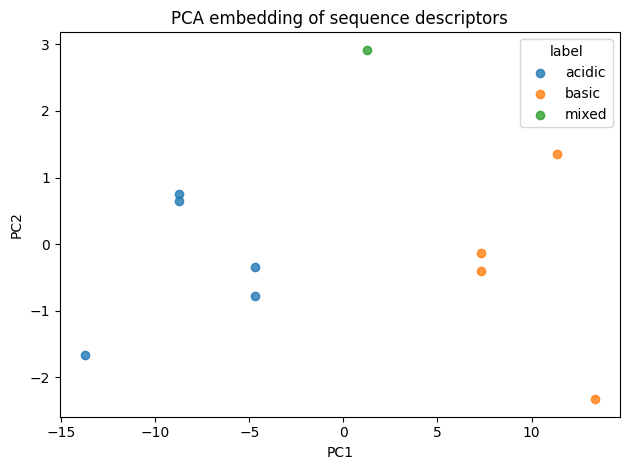

In [19]:
if result.embedding is not None:
    plt.figure(figsize=(5, 4))
    plot_embedding(
        result.embedding,
        y=result.y,
        labels=["PC1", "PC2"],
        title="PCA embedding of sequence descriptors",
    )
    plt.tight_layout()
    plt.show()
else:
    print("No embedding available (project_method=None was used).")

## 6. Using `RoxyHelpers.basic_eda_report` on any feature matrix

The `basic_eda_report` helper is agnostic to the origin of the features.
It simply builds a `DatasetReport` and renders it as Markdown and HTML.

Here we reuse the combined feature matrix `result.X` and the labels
`result.y`.


In [20]:
report2, md2, html2 = RoxyHelpers.basic_eda_report(
    result.X,
    y=result.y,
    dataset_name="Toy sequences (reused features)",
    task_type=None,  # let the helper infer task type
)

md2.splitlines()[:30]

/home/david/Desktop/library_implementation/roxy_library/roxy/report/markdown.py:145: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[float_cols] = df[float_cols].applymap(


['# Roxy dataset report — Toy sequences (reused features)',
 '',
 '## Overview',
 '',
 '- **Samples:** `10`',
 '- **Features:** `41`',
 '- **Task type:** `classification`',
 '- **Class distribution:**',
 '  - `acidic`: `5`',
 '  - `basic`: `4`',
 '  - `mixed`: `1`',
 '',
 '## Feature summary',
 '',
 '| name | dtype | n_missing | missing_ratio | n_unique | mean | std | min | max | skewness | kurtosis |',
 '| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |',
 '| length | float64 | 0 | 0.000 | 1 | 20.000 | 0.000 | 20.000 | 20.000 | 0.000 | 0.000 |',
 '| aa_frac_C | float64 | 0 | 0.000 | 2 | 0.005 | 0.016 | 0.000 | 0.050 | 3.162 | 10.000 |',
 '| aa_frac_G | float64 | 0 | 0.000 | 4 | 0.060 | 0.115 | 0.000 | 0.300 | 1.751 | 1.543 |',
 '| aa_frac_H | float64 | 0 | 0.000 | 2 | 0.005 | 0.016 | 0.000 | 0.050 | 3.162 | 10.000 |',
 '| aa_frac_A | float64 | 0 | 0.000 | 4 | 0.115 | 0.140 | 0.000 | 0.300 | 0.496 | -2.095 |',
 '| aa_frac_N | float64 | 0 | 0.000 | 2 | 0.005 | 0.016 | 

In [21]:
from IPython.display import HTML

HTML(html2)

name,dtype,n_missing,missing_ratio,n_unique,mean,std,min,max,skewness,kurtosis
length,float64,0,0.0,1,20.000,0.000,20.000,20.000,0.000,0.000
aa_frac_C,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_G,float64,0,0.0,4,0.060,0.115,0.000,0.300,1.751,1.543
aa_frac_H,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_A,float64,0,0.0,4,0.115,0.140,0.000,0.300,0.496,-2.095
aa_frac_N,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_D,float64,0,0.0,6,0.170,0.192,0.000,0.500,0.740,-0.848
aa_frac_L,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000
aa_frac_R,float64,0,0.0,5,0.120,0.192,0.000,0.500,1.345,0.268
aa_frac_T,float64,0,0.0,2,0.005,0.016,0.000,0.050,3.162,10.000


## 7. Summary

In this notebook we have:

- Built a small toy dataset of protein-like sequences with labels.
- Used `RoxyHelpers.describe_sequences` to:
  - create a `RoxyDataset`,
  - compute global (and optionally AAIndex-based) sequence descriptors,
  - assemble a feature matrix,
  - run EDA and build a `DatasetReport`,
  - obtain Markdown and HTML renderings,
  - compute a PCA embedding.
- Visualised the embedding using `plot_embedding` from `roxy.viz`.
- Reused the feature matrix with `RoxyHelpers.basic_eda_report` to
  generate another report.

These helpers are intended as “happy path” entry points that wrap Roxy's
core components into concise, reproducible workflows. For advanced use
cases, you can always fall back to the underlying primitives
(`RoxyDataset`, descriptor engines, EDA utilities, projection, viz and
report modules).
